# Clase 3 · Análisis exploratorio de datos II

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daniopitz/diplomado-cdd/blob/main/03_eda_bivariado_colab.ipynb)

Versión para **Google Colab**. Antes de trabajar, guarde su propia copia con `Archivo > Guardar una copia en Drive`.

Objetivos de la sesión: analizar relaciones entre pares de variables (correlación, grupos y tablas de contingencia), ajustar una primera regresión y graficar con buenas prácticas.

**El norte de todo esto son los modelos**: la correlación dice qué variables prometen como predictoras, la matriz ayuda a elegirlas, y la regresión de hoy ya es un modelo, el primero del diplomado.

## 1. Preparación

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# Seaborn: gráficos estadísticos de alto nivel, sobre Matplotlib
import seaborn as sns

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Alternativa sin URL: suba eod_stgo.zip, descomprima y use la ruta local:
# !unzip -q eod_stgo.zip -d .
# BASE = "eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
viajes.shape

(113591, 35)

In [4]:
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)
hogares.shape

(18264, 21)

Hoy usamos también la tabla de **personas**: una fila por persona encuestada, con su sexo, edad y ocupación.

In [5]:
personas = pd.read_csv(BASE + "personas.csv", sep=";", decimal=",", low_memory=False)
personas.shape

(60054, 39)

In [6]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
nombres = {0: "setosa", 1: "versicolor", 2: "virginica"}
iris_df["species"] = pd.Series(iris.target).map(nombres)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Los conceptos, con iris

### El gráfico de dispersión

**Objetivo:** relacionar el largo con el ancho del pétalo: ¿las flores de pétalos largos tienen también pétalos anchos?

La clase pasada describimos variables de a una; hoy las cruzamos de a dos. Para dos cuantitativas, el gráfico es la **dispersión** (scatter): cada punto es una fila, y sus coordenadas son los valores de las dos variables.

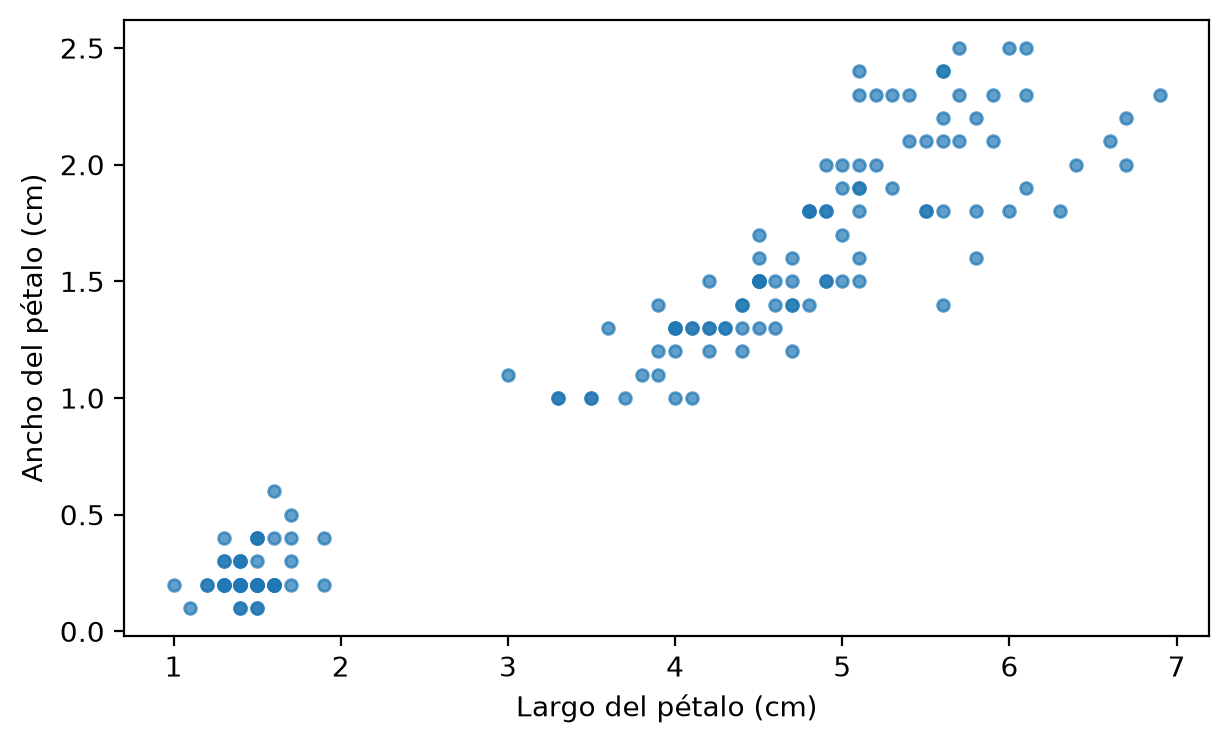

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
# s es el tamaño de cada punto; alpha, su transparencia
# (0 = invisible, 1 = sólido)
ax.scatter(iris_df["petal length (cm)"], iris_df["petal width (cm)"],
           s=18, alpha=0.7)
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
plt.show()

La nube sube en diagonal: pétalos más largos vienen con pétalos más anchos.

### La correlación

**Objetivo:** resumir la relación del scatter en un solo número comparable entre pares de variables.

La **correlación de Pearson** resume esa relación en un número entre −1 y 1: fuerza y signo de la relación lineal. En Pandas es un método de la columna:

In [8]:
iris_df["petal length (cm)"].corr(iris_df["petal width (cm)"])

np.float64(0.9628654314027961)

0,96: una relación lineal casi perfecta.

### La matriz de correlación

**Objetivo:** ver todas las relaciones entre las medidas de iris de una sola vez, y detectar variables redundantes.

Con más de dos variables, los pares se multiplican; la matriz los muestra todos de una vez. La diagonal es 1 (toda variable correlaciona perfecto consigo misma) y la matriz es simétrica:

In [9]:
# La columna species queda fuera: la correlación es entre cuantitativas
iris_df.drop(columns="species").corr().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.00,-0.12,0.87,0.82
sepal width (cm),-0.12,1.00,-0.43,-0.37
petal length (cm),0.87,-0.43,1.00,0.96
petal width (cm),0.82,-0.37,0.96,1.00


El 0,96 entre largo y ancho del pétalo dice que son casi redundantes: si hubiera que descartar una variable, la matriz es la evidencia para elegir cuál.

### La media por grupo

**Objetivo:** relacionar una cuantitativa (largo del pétalo) con una categórica (la especie): comparar el centro de cada grupo.

Para una cuantitativa contra una categórica ya conocemos el boxplot por grupo. Su versión numérica es `groupby`: parte la tabla por categoría, aplica el resumen a cada parte y junta los resultados. Es lo mismo que armamos a mano con `loc` y el for de la clase pasada, en una línea:

In [10]:
iris_df.groupby("species")["petal length (cm)"].mean()

species
setosa        1.462
versicolor    4.260
virginica     5.552
Name: petal length (cm), dtype: float64

1,46 / 4,26 / 5,55: las mismas medias que imprimimos con el zip, ahora de una línea.

## 3. La EOD: ¿los que menos ganan viajan más tiempo?

Una pregunta de equidad, con dos variables que no se implican por definición: el ingreso del hogar y la duración de los viajes. Las cruzamos a nivel de **comuna**: para cada una, el ingreso medio de sus hogares y la duración media de sus viajes. El ingreso está en la tabla de hogares, así que primero un merge. Y como las conclusiones son sobre la ciudad, se **pondera** (clase 2): cada media por comuna es la suma de w por x dividida por la suma de w, con el factor del día laboral normal.

Construir variables nuevas a partir de las existentes, como estos resúmenes por comuna o la distancia que calcularemos desde las coordenadas, es lo que en machine learning se llama **feature engineering**: preparar la materia prima de los modelos.

In [11]:
viajes_con_info = viajes.merge(hogares[["Hogar", "Comuna", "IngresoHogar", "NumVeh", "NumPer"]],on="Hogar")
viajes_con_info.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,Comuna,IngresoHogar,NumVeh,NumPer
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,1.000000,NaN,NaN,NaN,NaN,0.0,MAIPU,789356,0,4
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,1.052764,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4


In [12]:
viajes_final = viajes_con_info.dropna(subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()
viajes_final.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,Comuna,IngresoHogar,NumVeh,NumPer
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,1.000000,NaN,NaN,NaN,NaN,0.0,MAIPU,789356,0,4
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,1.052764,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4


In [13]:
# El numerador de cada media ponderada: w por x
w = viajes_final["FactorLaboralNormal"]

for col in ["IngresoHogar", "TiempoViaje", "NumVeh", "NumPer"]:
    viajes_final["w_" + col] = w * viajes_final[col]

viajes_final

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorFindesemanaEstival,CodigoTiempo,Comuna,IngresoHogar,NumVeh,NumPer,w_IngresoHogar,w_TiempoViaje,w_NumVeh,w_NumPer
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,0.0,MAIPU,789356,0,4,7.893560e+05,70.000000,0.0,4.000000
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,0.0,MAIPU,633883,0,4,7.145255e+05,118.358084,0.0,4.508879
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,0.0,MAIPU,633883,0,4,7.145255e+05,101.449786,0.0,4.508879
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,0.0,MAIPU,633883,0,4,7.145255e+05,61.997092,0.0,4.508879
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,0.0,MAIPU,633883,0,4,6.673289e+05,157.914534,0.0,4.211054
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112740,329271,32927104,3292710402,1,96.0,96.0,5.0,5.0,180,180,...,NaN,0.0,LA CISTERNA,750000,0,5,1.111578e+06,22.231559,0.0,7.410520
112741,329271,32927105,3292710501,1,96.0,95.0,5.0,5.0,180,643,...,NaN,0.0,LA CISTERNA,750000,0,5,1.111578e+06,11.856831,0.0,7.410520
112742,329271,32927105,3292710502,1,95.0,96.0,5.0,5.0,643,180,...,NaN,0.0,LA CISTERNA,750000,0,5,1.111578e+06,22.231559,0.0,7.410520
113173,359901,35990102,3599010201,1,335.0,70.0,5.0,4.0,627,6,...,NaN,0.0,SAN JOAQUIN,299472,0,4,2.449403e+05,36.805831,0.0,3.271629


In [14]:
# groupby y sum: por comuna, la suma de w y las sumas de w por x
suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
suma

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,IngresoHogar,NumVeh,NumPer,w_IngresoHogar,w_TiempoViaje,w_NumVeh,w_NumPer
Comuna,,,,,,,,,,,,,,,,,,,,,
BUIN,89661110,8966113146,896611316493,961,108285.0,111949.0,5979.0,5979.0,658345,658446,...,0.0,0.0,134.0,546475044,316,3501,7.052428e+08,32020.235435,410.078243,4524.432157
CALERA DE TANGO,64482902,6448291776,644829178694,701,65894.0,64974.0,2978.0,2960.0,444799,440821,...,0.0,0.0,123.0,382028274,452,2686,4.668899e+08,30455.905792,549.652548,3290.687984
CERRILLOS,80456874,8045689141,804568915428,903,203648.0,201903.0,1740.0,1746.0,101566,102724,...,0.0,0.0,46.0,444460094,341,2857,5.365975e+08,32291.613596,421.659246,3453.497919
CERRO NAVIA,119238371,11923839885,1192383990677,1432,289261.0,285565.0,2455.0,2459.0,176182,181066,...,0.0,0.0,123.0,514473060,371,4536,6.180795e+08,48622.725252,451.524027,5471.343361
COLINA,156220937,15622096652,1562209667243,1263,102390.0,103870.0,1415.0,1434.0,800165,799662,...,0.0,0.0,67.0,759559305,307,4900,9.198311e+08,47121.276054,386.236978,6035.397655
CONCHALI,126795031,12679506021,1267950603860,1336,118128.0,119639.0,1632.0,1653.0,165081,166925,...,0.0,0.0,270.0,740677765,298,4787,8.426084e+08,38234.833360,358.528527,5526.381809
EL BOSQUE,221988542,22198858985,2219885902417,2379,522713.0,521882.0,8754.0,8754.0,321967,328379,...,0.0,0.0,436.0,1088391729,723,8214,1.348067e+09,78619.628592,919.524076,10253.792705
EL MONTE,83633119,8363313714,836331372667,787,61756.0,62367.0,4335.0,4302.0,507189,502698,...,0.0,0.0,350.0,358888646,209,3140,4.357629e+08,34254.242379,265.967383,3845.078100
ESTACION CENTRAL,132553366,13255339089,1325533911007,1258,297735.0,295024.0,2477.0,2479.0,177009,177804,...,0.0,0.0,150.0,564378852,353,4079,6.804695e+08,42276.514398,437.980155,4975.472296


In [15]:
# Cada media ponderada: suma de w por x, dividida por suma de w
por_comuna = pd.DataFrame({
    "ingreso": suma["w_IngresoHogar"] / suma["FactorLaboralNormal"],
    "duracion": suma["w_TiempoViaje"] / suma["FactorLaboralNormal"],
    "vehiculos": suma["w_NumVeh"] / suma["FactorLaboralNormal"],
    "personas": suma["w_NumPer"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()

# Nos quedamos con las comunas con suficientes viajes
por_comuna = por_comuna[por_comuna["n"] >= 200]
por_comuna.head()

,Comuna,ingreso,duracion,vehiculos,personas,n
0,BUIN,611584.779504,27.767868,0.355619,3.923576,889
1,CALERA DE TANGO,609311.812531,39.746297,0.717321,4.294493,629
2,CERRILLOS,578682.733281,34.824237,0.454730,3.724355,760
3,CERRO NAVIA,457758.557018,36.010691,0.334405,4.052156,1113
4,COLINA,636524.561820,32.607995,0.267277,4.176504,1177


In [16]:
# Las comunas de mayor ingreso
por_comuna.sort_values("ingreso", ascending=False).head()

,Comuna,ingreso,duracion,vehiculos,personas,n
19,LO BARNECHEA,2.335469e+06,30.122934,1.693052,4.324674,1440
16,LA REINA,1.794268e+06,34.721604,1.426979,3.753801,1502
43,VITACURA,1.663449e+06,27.048377,1.804525,3.455132,1380
18,LAS CONDES,1.631805e+06,29.405219,1.539692,3.344254,4460
44,ÑUÑOA,1.504287e+06,31.317223,1.103716,3.516650,3146


In [17]:
# Y las de menor ingreso
por_comuna.sort_values("ingreso", ascending=False).tail()

,Comuna,ingreso,duracion,vehiculos,personas,n
15,LA PINTANA,499279.291904,49.232685,0.297321,5.093778,2351
21,LO PRADO,484657.589043,30.958393,0.262585,3.651183,953
11,ISLA DE MAIPO,470666.443066,44.404335,0.438021,4.495099,656
3,CERRO NAVIA,457758.557018,36.010691,0.334405,4.052156,1113
24,MELIPILLA,450330.377997,37.221498,0.397318,4.135675,861


Vitacura y Lo Barnechea en una punta; Cerro Navia y La Pintana en la otra. Ahora la pregunta, en un scatter de 45 puntos (uno por comuna, sin problemas de saturación):

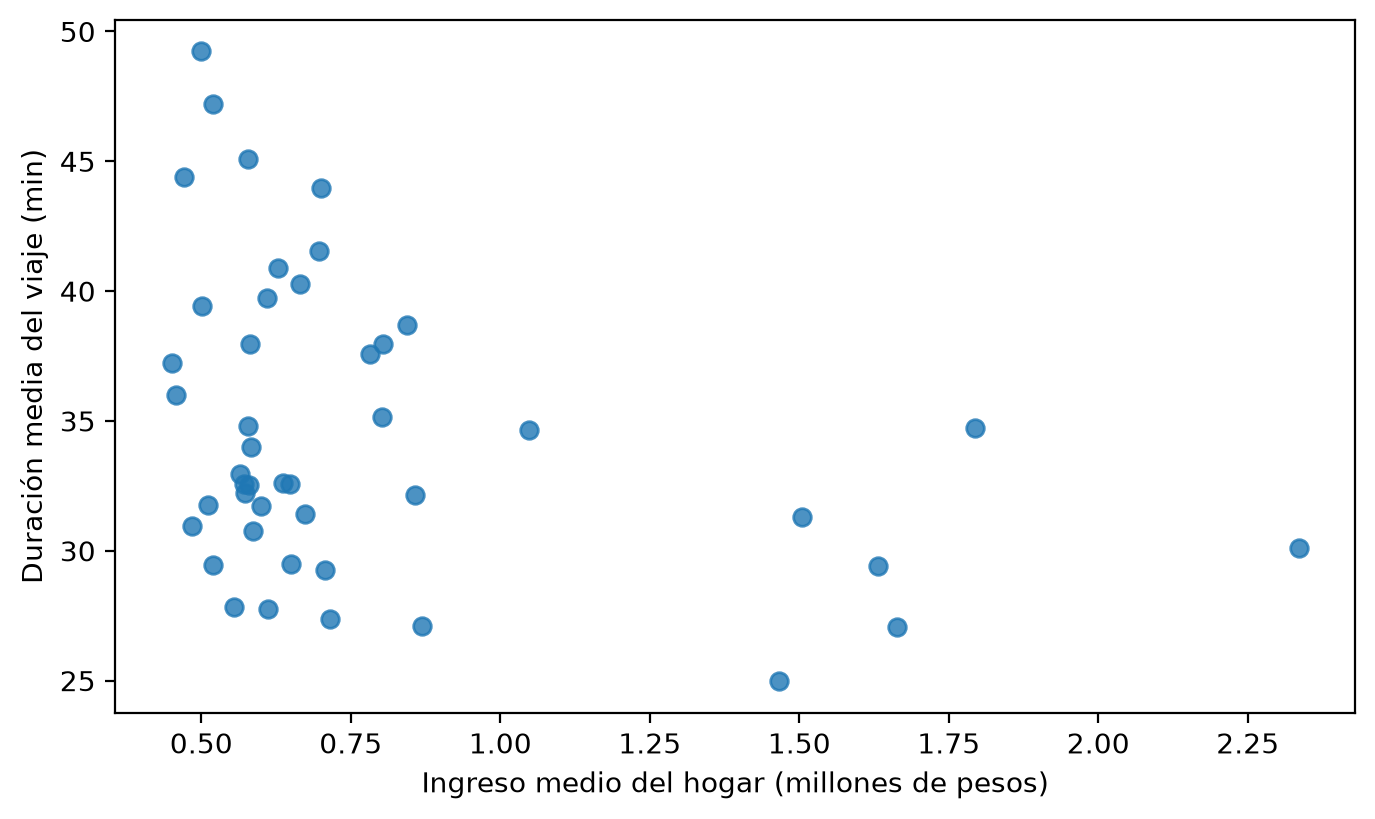

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(por_comuna["ingreso"] / 1e6, por_comuna["duracion"],
           s=40, alpha=0.8)
ax.set_xlabel("Ingreso medio del hogar (millones de pesos)")
ax.set_ylabel("Duración media del viaje (min)")
plt.show()

La tendencia baja: a mayor ingreso, viajes más cortos. ¿Cuánto? Los dos coeficientes:

In [19]:
x = por_comuna["ingreso"]
y = por_comuna["duracion"]

print("Pearson: ", round(x.corr(y), 2))
print("Spearman:", round(x.corr(y, method="spearman"), 2))

Pearson:  -0.34
Spearman: -0.33


−0,34 y −0,33: una asociación negativa moderada, parecida en ambos coeficientes. La relación existe y se reporta con su tamaño; no toda correlación interesante es 0,9.

### La matriz, con más variables

**Objetivo:** explorar qué otras características de las comunas se relacionan con la duración y con el ingreso, todas contra todas.

La tabla por comuna trae otras dos variables: vehículos y personas por hogar. Con cuatro variables hay seis pares; la matriz los muestra todos, y el heatmap la hace legible:

In [20]:
matriz = por_comuna[["ingreso", "duracion", "vehiculos", "personas"]].corr()
matriz.round(2)

,ingreso,duracion,vehiculos,personas
ingreso,1.00,-0.34,0.94,-0.34
duracion,-0.34,1.00,-0.26,0.65
vehiculos,0.94,-0.26,1.00,-0.32
personas,-0.34,0.65,-0.32,1.00


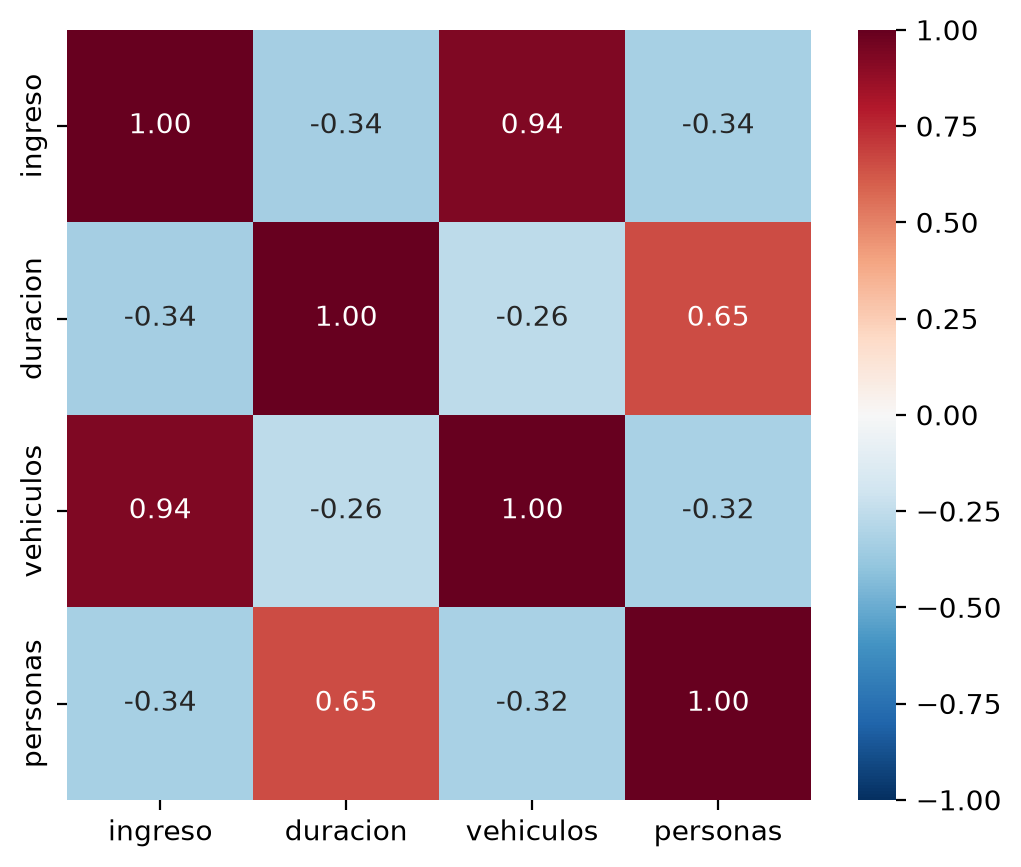

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
# Con seaborn, el heatmap con sus valores es una línea
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax)
plt.show()

Cómo se lee, par a par:

- **Ingreso y vehículos: 0,94.** La correlación más fuerte de la tabla: el ingreso compra autos.
- **Personas y duración: 0,65.** La sorpresa: el mejor acompañante de la duración no es el ingreso sino el tamaño del hogar. Las comunas de hogares grandes promedian viajes más largos.
- **Ingreso y duración: −0,34.** La asociación de equidad que ya vimos, moderada.
- **Ingreso y personas: −0,34.** Los hogares de las comunas de mayor ingreso son más chicos.

La matriz no solo describe: sugiere qué variables mirar después (personas por hogar acaba de ganarse un análisis propio) y cuáles son redundantes.

### Los rangos, a mano

**Objetivo:** entender de dónde sale Spearman, calculando los rangos de cinco comunas conocidas.

Para ver de dónde sale Spearman, `rank()` asigna a cada valor su posición al ordenar; con cinco comunas se puede seguir el cálculo completo:

In [22]:
cinco = por_comuna[por_comuna["Comuna"].isin(
    ["VITACURA", "PROVIDENCIA", "SANTIAGO", "PUENTE ALTO", "CERRO NAVIA"])].copy()

cinco.head()

,Comuna,ingreso,duracion,vehiculos,personas,n
3,CERRO NAVIA,4.577586e+05,36.010691,0.334405,4.052156,1113
30,PROVIDENCIA,1.465410e+06,24.971180,1.031311,2.958569,2315
32,PUENTE ALTO,6.646129e+05,40.268681,0.526383,4.136014,6066
41,SANTIAGO,7.149814e+05,27.356982,0.308495,2.980121,3406
43,VITACURA,1.663449e+06,27.048377,1.804525,3.455132,1380


In [23]:
# rank() asigna a cada valor su posición al ordenar
cinco["rango_ingreso"] = cinco["ingreso"].rank()
cinco["rango_duracion"] = cinco["duracion"].rank()
cinco[["Comuna", "ingreso", "duracion", "rango_ingreso", "rango_duracion"]]

,Comuna,ingreso,duracion,rango_ingreso,rango_duracion
3,CERRO NAVIA,4.577586e+05,36.010691,1.0,4.0
30,PROVIDENCIA,1.465410e+06,24.971180,4.0,1.0
32,PUENTE ALTO,6.646129e+05,40.268681,2.0,5.0
41,SANTIAGO,7.149814e+05,27.356982,3.0,3.0
43,VITACURA,1.663449e+06,27.048377,5.0,2.0


Los rangos altos de ingreso van con rangos bajos de duración: eso es una asociación negativa, contada solo con posiciones.

Y la advertencia que acompaña a toda correlación: **correlación no es causalidad**. Que dos variables se muevan juntas no dice que una cause a la otra; con datos observacionales reportamos asociación.

## 4. Grupos y tablas de contingencia

**Objetivo:** relacionar dos categóricas, sexo y modo de transporte: ¿se mueven distinto hombres y mujeres en Santiago?

Para dos **categóricas**, el resumen es la tabla de contingencia: cuenta las combinaciones. Veamos el modo de transporte según el sexo. El sexo está en la tabla de personas, así que primero los merges (el modo, igual que la clase pasada; el sexo, con la llave compuesta Hogar y Persona):

In [24]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

viajes_modo = (viajes
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID")
    # La llave compuesta: la persona 1 del hogar 2 no es la del hogar 3
    .merge(personas[["Hogar", "Persona", "Sexo"]], on=["Hogar", "Persona"]))

viajes_modo["ModoAgrupado"] = viajes_modo["NombreModo"].where(
    ~viajes_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")
len(viajes_modo)

113591

In [25]:
viajes_modo.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,ModoDifusion,ID,NombreModo,Sexo,ModoAgrupado
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado)
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,NaN,NaN,NaN,0.0,2,2,Bip!,1,Bip! (solo o combinado)
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,NaN,NaN,NaN,0.0,2,2,Bip!,1,Bip! (solo o combinado)
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado)
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado)


In [26]:
# El sexo viene como código; el diccionario lo traduce
viajes_modo["SexoNombre"] = viajes_modo["Sexo"].map({1: "Hombre", 2: "Mujer"})

viajes_modo.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,ModoDifusion,ID,NombreModo,Sexo,ModoAgrupado,SexoNombre
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado),Mujer
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,NaN,NaN,0.0,2,2,Bip!,1,Bip! (solo o combinado),Hombre
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,NaN,NaN,0.0,2,2,Bip!,1,Bip! (solo o combinado),Hombre
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado),Mujer
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,NaN,NaN,0.0,2,2,Bip!,2,Bip! (solo o combinado),Mujer


In [27]:
tabla=viajes_modo.pivot_table(
    index="SexoNombre", columns="ModoAgrupado", aggfunc="size", fill_value=0
)
tabla

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,14964,2888,17073,12711,4445,598,1125
Mujer,11473,982,18704,21116,4040,1064,2408


In [28]:
(tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,27.8,5.4,31.7,23.6,8.3,1.1,2.1
Mujer,19.2,1.6,31.3,35.3,6.8,1.8,4.0


El atajo para lo mismo: `pd.crosstab` cuenta combinaciones y trae `normalize="index"` incorporado (pivot_table no lo tiene, por eso el div de arriba):

In [29]:
(pd.crosstab(viajes_modo["SexoNombre"], viajes_modo["ModoAgrupado"],
             normalize="index") * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,27.8,5.4,31.7,23.6,8.3,1.1,2.1
Mujer,19.2,1.6,31.3,35.3,6.8,1.8,4.0


Y el cuidado de siempre: estas proporciones describen la muestra. Para hablar de la ciudad se pondera, sumando factores de expansión en vez de contar viajes (aquí, el día laboral normal):

In [30]:
lab = viajes_modo.dropna(subset=["FactorLaboralNormal", "SexoNombre"])

# pivot_table con aggfunc="sum": suma los factores de cada celda
tabla = lab.pivot_table(values="FactorLaboralNormal", index="SexoNombre",
                        columns="ModoAgrupado", aggfunc="sum")

# Cada fila dividida por su total, en porcentaje
(tabla.div(tabla.sum(axis=1), axis=0) * 100).round(1)

ModoAgrupado,Auto,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
SexoNombre,,,,,,,
Hombre,28.4,6.0,27.9,26.6,7.7,1.2,2.1
Mujer,19.1,1.9,26.2,40.3,6.2,1.9,4.5


Ponderado, el contraste se acentúa: las mujeres caminan más (40% contra 27%) y los hombres usan más el auto (28% contra 19%) y la bicicleta (6% contra 1,9%). Un hallazgo real de género y movilidad, sacado con dos tablas y un merge.

## 5. La primera regresión

**Objetivo:** convertir la asociación ingreso-duración en una función: una recta que resuma la relación y permita predecir.

La correlación dijo cuánto se asocian el ingreso y la duración (−0,34); la **regresión lineal** dibuja la recta que mejor resume esa asociación (la de mínimos cuadrados: la que deja la menor suma de errores al cuadrado). Esa recta es un **modelo**: una función que resume los datos y permite predecir. Es el primero del diplomado, y todo lo que viene (más variables, regularización, clasificación) son versiones más ricas de esta misma idea.

El método tiene nombre y fórmula: **mínimos cuadrados ordinarios** (OLS), la recta que minimiza la suma de los errores al cuadrado. Su pendiente y su intercepto son

$$b = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sum_i (x_i - \bar{x})^2} \qquad a = \bar{y} - b\,\bar{x}$$

donde $x_i$ e $y_i$ son los valores de cada caso (aquí, cada comuna), $\bar{x}$ e $\bar{y}$ sus medias, $b$ la pendiente y $a$ el intercepto.

Y qué significa cada número, dibujado:

![Pendiente e intercepto](https://raw.githubusercontent.com/daniopitz/diplomado-cdd/main/figuras/pendiente_intercepto.png)

La librería de hoy es NumPy: `np.polyfit` implementa exactamente esta fórmula (el 1 pide grado 1, una recta). En las clases 6 y 7 usaremos scikit-learn y statsmodels, que agregan diagnósticos e inferencia:

In [31]:
pendiente, intercepto = np.polyfit(por_comuna["ingreso"] / 1e6,
                                   por_comuna["duracion"], 1)

print("Pendiente: ", round(pendiente, 1), "minutos por millón")
print("Intercepto:", round(intercepto, 1), "minutos")

Pendiente:  -4.8 minutos por millón
Intercepto: 38.3 minutos


Los dos números se interpretan: por cada millón adicional de ingreso medio, la duración media baja casi **5 minutos**; y el intercepto (38 minutos) es donde la recta corta el eje. Como por_comuna viene ponderada, esta recta ya habla de la ciudad. Ahora la recta sobre los puntos:

In [32]:
# Para dibujar una recta bastan dos puntos: la evaluamos en el
# ingreso mínimo y el máximo de las comunas
x = np.array([por_comuna["ingreso"].min(), por_comuna["ingreso"].max()]) / 1e6
x

array([0.45033038, 2.33546874])

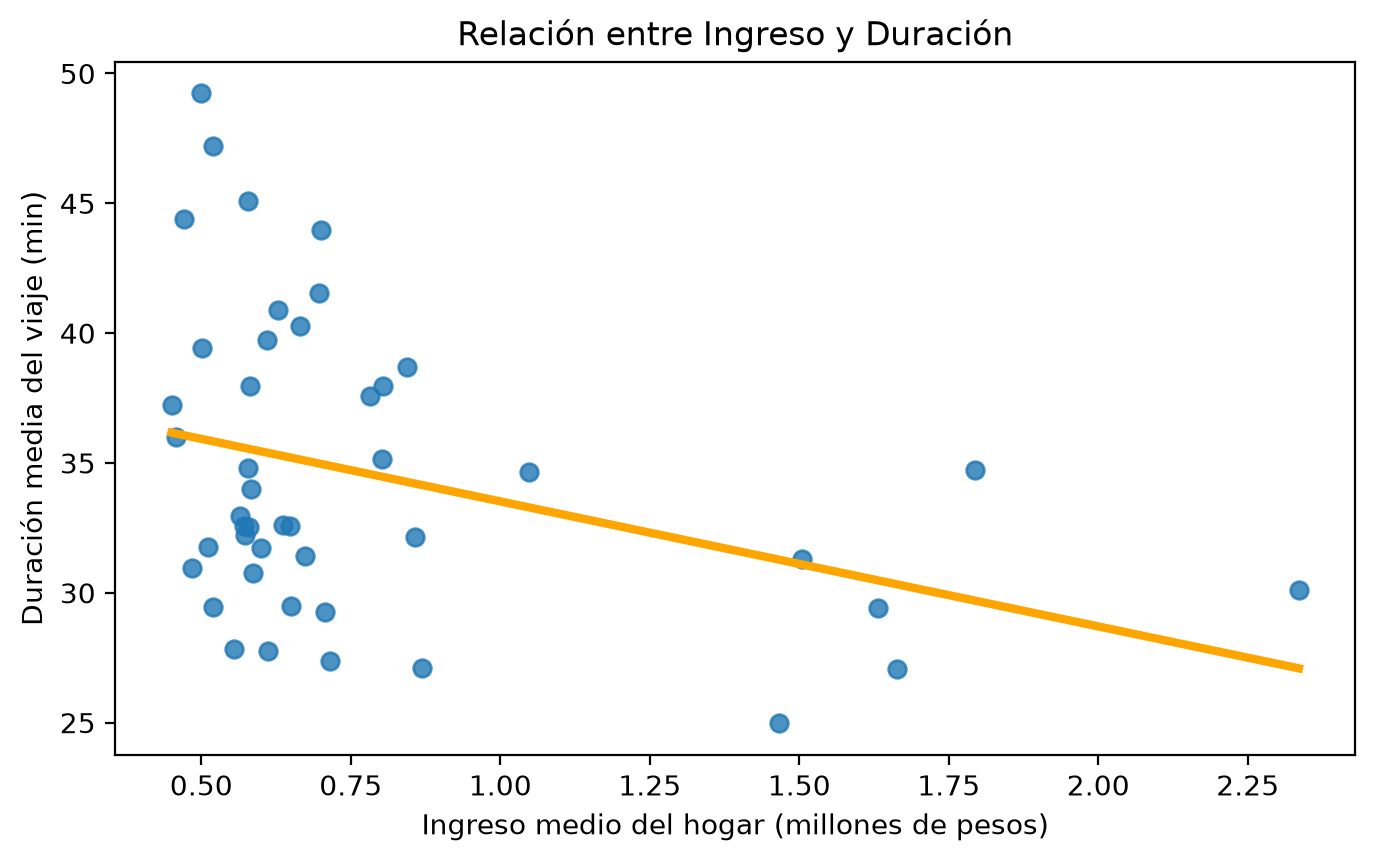

In [33]:
#Grafico de dispersion
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(por_comuna["ingreso"] / 1e6, por_comuna["duracion"],
           s=40, alpha=0.8)
#Dibujar recta
ax.plot(x, intercepto + pendiente * x, color="orange", lw=3)
ax.set_xlabel("Ingreso medio del hogar (millones de pesos)")
ax.set_ylabel("Duración media del viaje (min)")
ax.set_title("Relación entre Ingreso y Duración")
plt.show()

### La misma recta, con statsmodels

**Objetivo:** conocer la librería estadística con que seguiremos trabajando, verificando que entrega el mismo modelo.

Como complemento, la misma regresión con **statsmodels**, la librería estadística que seguiremos usando en las clases 5, 6 y 7, donde la explicaremos en detalle. `add_constant` agrega el intercepto y `OLS(...).fit()` ajusta por mínimos cuadrados, el mismo método de recién:

In [34]:
import statsmodels.api as sm

# X: la variable explicativa

X = sm.add_constant(por_comuna["ingreso"] / 1e6)

# modelo: el modelo de regresión o dependiente, que es la variable que queremos explicar
modelo = sm.OLS(por_comuna["duracion"], X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               duracion   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     5.707
Date:                Tue, 01 Sep 2026   Prob (F-statistic):             0.0214
Time:                        13:41:28   Log-Likelihood:                -139.50
No. Observations:                  45   AIC:                             283.0
Df Residuals:                      43   BIC:                             286.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.3352      1.773     21.622      0.0

La tabla es grande, pero hoy basta con tres lecturas: los **coef** (const 38,3 y pendiente −4,8, idénticos a polyfit), el **R-squared** (0,12, nuestro r al cuadrado) y la columna **P>|t|**: ese es el famoso valor p, que para la pendiente da 0,021. Qué significa y por qué importa es exactamente el tema de la clase 5; el resto de la tabla se irá iluminando en las clases siguientes.

### Usar la recta

**Objetivo:** usar el modelo para predecir y para encontrar comunas que viajan más (o menos) de lo que su ingreso explica.

La recta es una función que sirve para **predecir** (¿qué duración esperamos en una comuna de ingreso medio 1 millón?) y para medir **residuos**: cuánto se aleja cada comuna de lo que su ingreso predice.

In [35]:
# Predicción para una comuna de ingreso medio 1 millón
print(round(intercepto + pendiente * 1.0, 1), "minutos")

33.5 minutos


In [36]:
# El residuo: lo observado menos lo predicho
por_comuna["prediccion"] = intercepto + pendiente * por_comuna["ingreso"] / 1e6
por_comuna["residuo"] = por_comuna["duracion"] - por_comuna["prediccion"]

# Las comunas que viajan MÁS de lo que su ingreso predice
por_comuna.nlargest(5, "residuo")[["Comuna", "duracion", "prediccion", "residuo"]].round(1)

,Comuna,duracion,prediccion,residuo
15,LA PINTANA,49.2,35.9,13.3
27,PEÑAFLOR,47.2,35.8,11.4
25,PADRE HURTADO,45.1,35.6,9.6
33,QUILICURA,44.0,35.0,9.0
11,ISLA DE MAIPO,44.4,36.1,8.3


In [37]:
# Y las que viajan MENOS de lo que su ingreso predice
por_comuna.nsmallest(5, "residuo")[["Comuna", "duracion", "prediccion", "residuo"]].round(1)

,Comuna,duracion,prediccion,residuo
38,SAN JOAQUIN,27.8,35.7,-7.8
0,BUIN,27.8,35.4,-7.6
41,SANTIAGO,27.4,34.9,-7.5
39,SAN MIGUEL,27.1,34.2,-7.0
37,SAN BERNARDO,29.5,35.8,-6.4


### El impacto de sacar una fila

**Objetivo:** medir cuánto cambian la correlación y la recta al sacar una sola fila, comparando con y sin.

La clase pasada medimos el impacto de sacar filas comparando un resumen con y sin (la desviación se movía; el IQR no). Con dos variables el mismo experimento se amplifica: una fila mueve varios resúmenes a la vez, y no a todos por igual. La comuna de ingreso más extremo es Lo Barnechea; la sacamos y comparamos todo:

In [38]:
sin_lb = por_comuna[por_comuna["Comuna"] != "LO BARNECHEA"]

print("Con Lo Barnechea: r =", round(por_comuna["ingreso"].corr(por_comuna["duracion"]), 2))
print("Sin Lo Barnechea: r =", round(sin_lb["ingreso"].corr(sin_lb["duracion"]), 2))

Con Lo Barnechea: r = -0.34
Sin Lo Barnechea: r = -0.34


In [39]:
pend2, inter2 = np.polyfit(sin_lb["ingreso"] / 1e6, sin_lb["duracion"], 1)

print("Pendiente  con:", round(pendiente, 1), "| sin:", round(pend2, 1))
print("Intercepto con:", round(intercepto, 1), "| sin:", round(inter2, 1))

Pendiente  con: -4.8 | sin: -5.8
Intercepto con: 38.3 | sin: 39.0


Una sola comuna de 45 no mueve la correlación (−0,34 en ambos casos), pero cambia la pendiente en un quinto (−4,8 a −5,8): cada resumen tiene su propia sensibilidad. Por eso el impacto de sacar una fila se mide siempre con y sin, y sobre **todos** los resúmenes que el análisis usa. Los puntos extremos en x, como Lo Barnechea, tienen nombre propio en regresión (puntos de apalancamiento) y los verán formalmente en la clase 6.

Una advertencia de escala: en esta tabla agregada, sacar una "fila" es sacar una comuna completa, miles de viajes. Repitamos el experimento donde corresponde: en un modelo desagregado, hogar por hogar.

### Otro modelo: la motorización

**Objetivo:** modelar cuántos vehículos tiene un hogar según su ingreso, ahora con datos desagregados (un hogar por fila).

Los modelos de propiedad de vehículos son estándar en ingeniería de transporte: ¿cuántos autos tendrá un hogar según su ingreso? Aquí cada fila es un hogar de verdad, 18.264, no un agregado. Como la conclusión es sobre la ciudad, usamos las fórmulas ponderadas; las medias son las de la clase 2,

$$\bar{x}_w = \frac{\sum_i w_i\,x_i}{\sum_i w_i} \qquad \bar{y}_w = \frac{\sum_i w_i\,y_i}{\sum_i w_i}$$

y la pendiente y el intercepto, los de mínimos cuadrados con cada término pesado por su factor $w_i$:

$$b_w = \frac{\sum_i w_i\,(x_i - \bar{x}_w)(y_i - \bar{y}_w)}{\sum_i w_i\,(x_i - \bar{x}_w)^2} \qquad a_w = \bar{y}_w - b_w\,\bar{x}_w$$

donde $w_i$ es el factor de expansión del hogar $i$, y $\bar{x}_w$, $\bar{y}_w$ las medias ponderadas.

El código que sigue es esta fórmula, línea por línea:

In [40]:
h = hogares.dropna(subset=["IngresoHogar", "NumVeh", "Factor"]).copy()

x = h["IngresoHogar"] / 1e6
y = h["NumVeh"]
w = h["Factor"]

# Las medias ponderadas, como en la clase 2
xw = (w * x).sum() / w.sum()
yw = (w * y).sum() / w.sum()
print(round(xw, 2), round(yw, 2))

0.73 0.57


In [41]:
# La fórmula de la pendiente ponderada, tal cual
pend_h = (w * (x - xw) * (y - yw)).sum() / (w * (x - xw)**2).sum()
inter_h = yw - pend_h * xw

print("Pendiente: ", round(pend_h, 2), "vehículos por millón")
print("Intercepto:", round(inter_h, 2), "vehículos")

Pendiente:  0.5 vehículos por millón
Intercepto: 0.2 vehículos


La misma regresión ponderada existe en statsmodels con nombre propio: **WLS** (weighted least squares, mínimos cuadrados ponderados), que recibe los pesos en `weights`:

In [42]:
# WLS: la versión ponderada de OLS
modelo_w = sm.WLS(y, sm.add_constant(x), weights=w).fit()

# Lado a lado y con más decimales: ¿dan lo mismo?
print("Fórmula a mano : pendiente", round(pend_h, 4),
      "| intercepto", round(inter_h, 4))
print("statsmodels WLS: pendiente", round(modelo_w.params["IngresoHogar"], 4),
      "| intercepto", round(modelo_w.params["const"], 4))

Fórmula a mano : pendiente 0.5014 | intercepto 0.1999
statsmodels WLS: pendiente 0.5014 | intercepto 0.1999


Iguales hasta el último decimal: la fórmula a mano y la librería son el mismo método.

**Medio vehículo más por cada millón** de ingreso. Y un detalle que conecta con la matriz: a nivel de hogar la correlación es 0,47, pero agregada por comuna era 0,94. Los promedios esconden la variabilidad individual; la correlación entre agregados casi siempre se ve más impresionante que la real.

Ahora la pregunta del inicio: ¿qué pasa si saco los atípicos de la **variable que quiero predecir**? Según Tukey, en vehículos la cerca queda en 2,5: los hogares con 3 autos o más son atípicos.

In [43]:
q1, q3 = h["NumVeh"].quantile([0.25, 0.75])
corte = q3 + 1.5 * (q3 - q1)
sa = h[h["NumVeh"] <= corte]
sa

,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18259,700990,7,785,BUIN,339104.1011,6263063.925,24-11-2013,domingo,2,1,...,0,1,1,1,NaN,0,100000,0,300000,75.526031
18260,706781,2,69,CERRO NAVIA,338539.1741,6299539.203,24-11-2013,domingo,2,1,...,0,2,2,1,NaN,0,140000,0,695186,174.348663
18261,706791,2,69,CERRO NAVIA,338563.2201,6299580.118,24-11-2013,domingo,2,1,...,0,0,0,1,NaN,0,200000,0,396715,71.358963
18262,743813,5,244,LA GRANJA,349410.2812,6289668.962,24-11-2013,domingo,2,1,...,0,0,0,1,NaN,0,80000,0,318005,68.410446


In [44]:
# La misma fórmula ponderada, sobre los datos recortados
x2= sa["IngresoHogar"] / 1e6
y2=sa["NumVeh"]
w2=sa["Factor"]

In [45]:
xw2 = (w2 * x2).sum() / w2.sum()
yw2 = (w2 * y2).sum() / w2.sum()
pend_s = (w2 * (x2 - xw2) * (y2 - yw2)).sum() / (w2 * (x2 - xw2)**2).sum()
inter_s = yw2 - pend_s * xw2

print("Hogares eliminados:", len(h) - len(sa))
print("Pendiente con:", round(pend_h, 2), "| sin:", round(pend_s, 2))

Hogares eliminados: 236
Pendiente con: 0.5 | sin: 0.44


In [46]:
#ingreso
x.head()

0    0.450845
1    1.019369
2    0.080000
3    0.559259
4    0.710309
Name: IngresoHogar, dtype: float64

In [47]:
#numveh
y.head()

0    1
1    1
2    0
3    0
4    0
Name: NumVeh, dtype: int64

In [48]:
#ingreso min y max
xr = np.array([x.min(), x.max()])
xr

array([ 0. , 14.8])

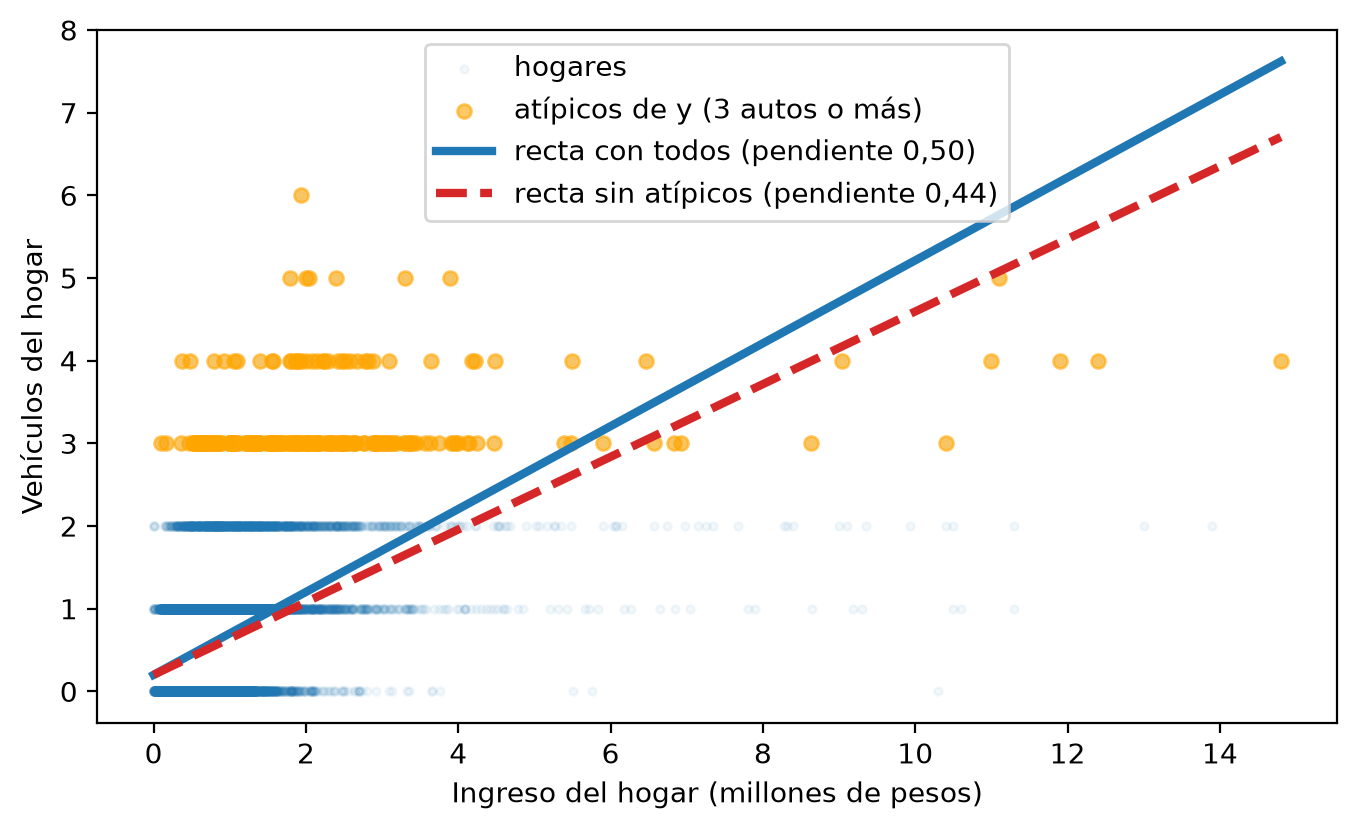

In [49]:
# El impacto, dibujado: las dos rectas sobre los hogares.
# s es el tamaño de cada punto; alpha, su transparencia: con
# 18 mil hogares, alpha=0.05 deja ver dónde se acumulan
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x, y, alpha=0.05, s=8, label="hogares") #datos completos
ax.scatter(x[y > corte], y[y > corte], s=25, color="orange",alpha=0.6, label="atípicos de y (3 autos o más)") #datos filtrados
ax.plot(xr, inter_h + pend_h * xr, lw=3, color="C0",
        label="recta con todos (pendiente 0,50)") # recta considerando todos los hogares
ax.plot(xr, inter_s + pend_s * xr, lw=3, ls="--", color="C3",
        label="recta sin atípicos (pendiente 0,44)") # recta filtrando hogares

ax.set_xlabel("Ingreso del hogar (millones de pesos)")
ax.set_ylabel("Vehículos del hogar")
ax.legend()
plt.show()

El gráfico muestra el mecanismo: al perder los puntos naranjos de arriba, la recta punteada gira hacia abajo. Sacar 236 hogares de 18 mil (el 1,3%) **aplana la pendiente de 0,50 a 0,44**: el modelo queda ciego justo a los hogares más motorizados, que son el fenómeno que un modelo de motorización quiere capturar. Esos atípicos no eran errores. La regla: los atípicos de la variable objetivo se **investigan**, y se eliminan solo con una razón de dominio (como los viajes imposibles de la clase 2), nunca por rutina ni para que el ajuste se vea mejor.

La Pintana viaja 17 minutos más de lo que su ingreso predice; Santiago, 8 menos. El residuo separa el efecto del ingreso del resto: lo que queda arriba huele a periferia (distancia al empleo), lo que queda abajo, a centralidad. Los residuos son una herramienta de hallazgos, no solo un error.

Una pregunta queda deliberadamente abierta: ¿es esta pendiente "real" o podría ser azar de estos 45 puntos? Responderla exige las herramientas de la clase 5: hipótesis, valor p y significancia. Por ahora, sepan que la pregunta existe y que tiene respuesta formal.

Esto es un primer contacto: en las clases 6 y 7 la regresión se profundiza (varias variables, diagnósticos y regularización).

## 6. Visualización: muchos puntos y escalas

**Objetivo:** resolver dos problemas prácticos de graficar datos reales: la saturación con muchos puntos y las colas largas.

Para el primero necesitamos muchos puntos: usaremos la distancia de cada viaje, que la EOD trae en su propia tabla, `DistanciaViaje.csv`:

In [50]:
distancias = pd.read_csv(BASE + "DistanciaViaje.csv", sep=";", decimal=",")
distancias.head()

,Viaje,DistEuclidiana,DistManhattan,Imputada
0,1000100101,-1,-1,0
1,1000100102,-1,-1,0
2,1000100201,-1,-1,0
3,1000100202,-1,-1,0
4,1000100203,-1,-1,0


Ahí están los −1: el tercer faltante disfrazado del curso (tras las coordenadas en 0 y los códigos 999). Contémoslos, y unamos la distancia a los viajes con su llave:

In [51]:
# ¿Cuántos viajes no tienen distancia?
(distancias["DistEuclidiana"] < 0).sum()

np.int64(10857)

In [52]:
ok = viajes.merge(distancias, on="Viaje")

# Fuera los -1 (faltantes) y los viajes sin duración
ok = ok[ok["DistEuclidiana"] >= 0].dropna(subset=["TiempoViaje"])

# De metros a kilómetros
ok["DistKm"] = ok["DistEuclidiana"] / 1000
len(ok)

102483

In [53]:
ok["DistKm"].describe().round(2)

count    102483.00
mean          6.23
std          13.05
min           0.00
25%           0.83
50%           3.06
75%           8.54
max        1258.47
Name: DistKm, dtype: float64

Mediana 3 km, pero un máximo de 1.258: imposible dentro de la Región Metropolitana (el checklist de rangos válidos de la clase 2, otra vez). Cortamos en 150 km, el ancho generoso de la región:

In [54]:
ok = ok[ok["DistKm"] <= 150]
len(ok)

102422

Correlación 1,0 y un cuarto de metro de diferencia: la columna oficial es exactamente la distancia euclidiana sobre las coordenadas. Reproducir una variable es la mejor manera de entender sus metadatos, y de paso validamos la tabla.

Con 102 mil puntos, el scatter normal se satura: los puntos se tapan y el gráfico miente. El remedio más simple es la transparencia (`alpha`):

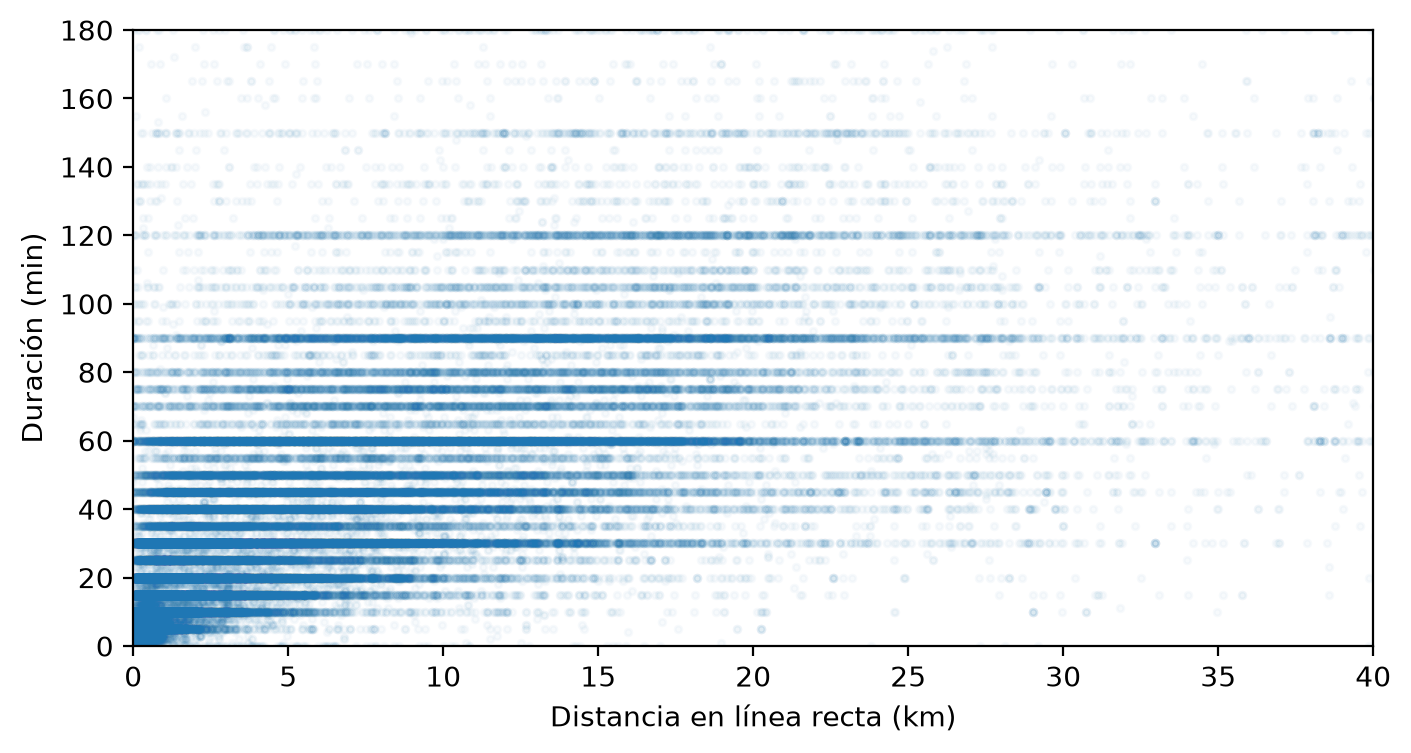

In [55]:
fig, ax = plt.subplots(figsize=(8, 4))
# alpha muy bajo: el color se acumula donde hay muchos puntos
ax.scatter(ok["DistKm"], ok["TiempoViaje"], s=6, alpha=0.03)
ax.set_xlim(0, 40)
ax.set_ylim(0, 180)
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
plt.show()

Las franjas horizontales son los tiempos redondeados (30, 45, 60): la moda de la clase 2, ahora en dos dimensiones. La alternativa es `hexbin`, donde el color cuenta los viajes por celda:

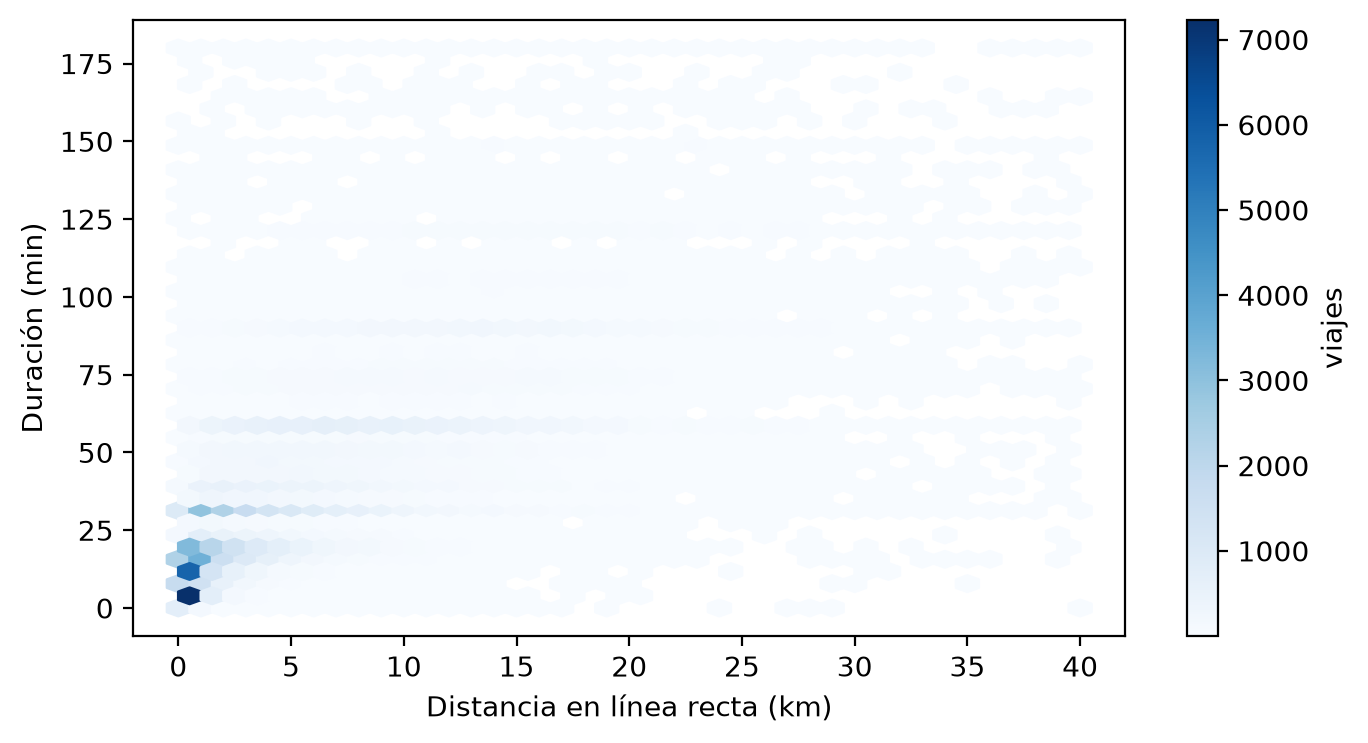

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
hb = ax.hexbin(ok["DistKm"], ok["TiempoViaje"], gridsize=40,
               cmap="Blues", mincnt=1, extent=(0, 40, 0, 180))
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
fig.colorbar(hb, label="viajes")
plt.show()

In [57]:
print("Pearson: ", round(ok["DistKm"].corr(ok["TiempoViaje"]), 2))
print("Spearman:", round(ok["DistKm"].corr(ok["TiempoViaje"], method="spearman"), 2))

Pearson:  0.57
Spearman: 0.76


0,57 contra 0,76: cuando los dos coeficientes difieren, hay curvatura o atípicos, y la respuesta está en el gráfico (es el ejemplo de la diapo de Spearman).

El segundo problema: **colas largas**. Con variables como el ingreso, la escala lineal aplasta el 99% de los datos contra el borde; graficar el logaritmo reparte el espacio y la forma aparece:

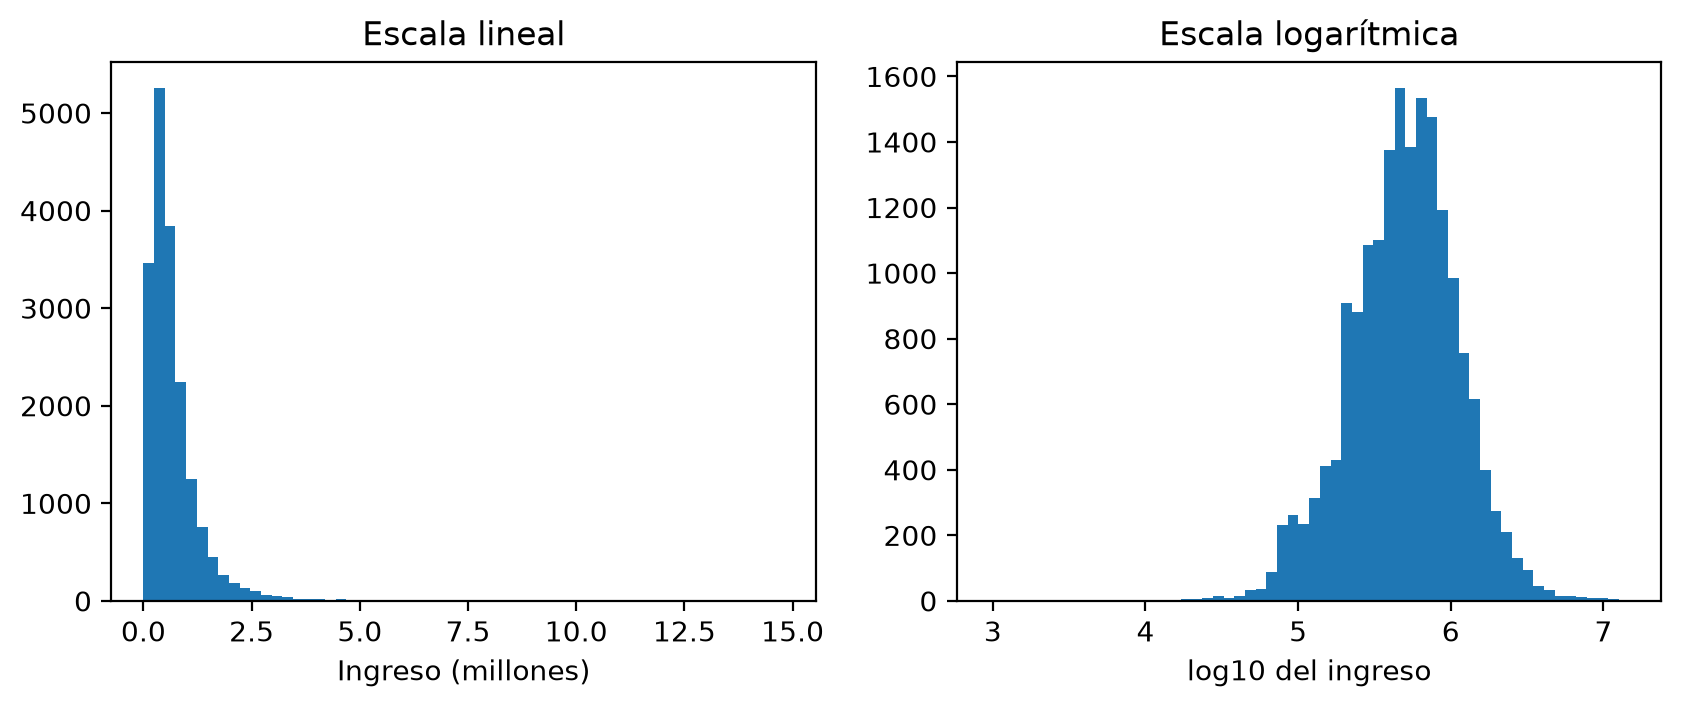

In [58]:
ingreso = hogares["IngresoHogar"].dropna()
# El logaritmo no acepta ceros
ingreso = ingreso[ingreso > 0]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(ingreso / 1e6, bins=60)
axes[0].set_title("Escala lineal")
axes[0].set_xlabel("Ingreso (millones)")
axes[1].hist(np.log10(ingreso), bins=60)
axes[1].set_title("Escala logarítmica")
axes[1].set_xlabel("log10 del ingreso")
plt.show()

En log10, un 6 es un millón de pesos y un 7, diez millones: cada paso del eje multiplica por 10.

## 7. Ejercicio (voluntario)

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. La matriz de correlación de sus variables cuantitativas. ¿Hay pares redundantes? ¿Cuáles descartaría?
2. Un scatter de las dos variables más relevantes para su pregunta, cuidando el overplotting si hay muchas filas.
3. Una tabla de contingencia o un groupby que cruce una categórica con su variable de interés.

Todo esto es material directo para el primer análisis exploratorio, que se entrega el lunes 15.

In [59]:
# Su solución


---

**Próxima clase (jueves 03-sep):** presentaciones breves de las ideas de proyecto (5 minutos por equipo, sin nota) y fundamentos de probabilidad. Recuerde: la formulación del Capstone se entrega el lunes 7 de septiembre.